# scVI evaluation plots for different histogram bin counts (rebuttal)

Mirrors `generate_plots_scvi_models_different_alpha_rebuttal.ipynb`, but varies **bins** instead of **alpha**.

- New AR runs: `bins \in {50, 80, 120, 150}` from `rebuttal_round2/new_results_different_bin_counts/`
- Manuscript baseline: Standard + AR at default `bins=100`, `alpha=0.0001`

Plots: lineplots vs `Atlas_cell_count`, `hue=ARtype`, `style=bins`.

In [1]:
from pathlib import Path
import os
import pickle
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "eval_scripts" else NOTEBOOK_DIR

BIN_RESULTS_ROOT = Path(
    "/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/"
    "rebuttal_round2/new_results_different_bin_counts"
)
CLASS_BIN_DIR = BIN_RESULTS_ROOT / "scVI-classification-evals-bins"
RECON_BIN_DIR = BIN_RESULTS_ROOT / "scVI-reconstruction-evals-bins"

CLASS_BASELINE_DIR = (
    REPO_ROOT / "result/test/sctab/zeinab-classification-evals-20250409-manuscript-version"
)
RECON_BASELINE_DIR = (
    REPO_ROOT / "result/test/sctab/zeinab-reconstruction-evals-20250409-manuscript-version"
)

FIG_DIR = Path(
    "/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/"
    "rebuttal_round2/figures/evals_for_different_bins"
)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_BINS = 100
DEFAULT_ALPHA = 0.0001
SEEDS = [42, 43, 44, 45, 46]
PALETTE = {"Standard": "darkgray", "AR": "brown"}

print("Classification (bins):", CLASS_BIN_DIR)
print("Reconstruction (bins):", RECON_BIN_DIR)
print("Figures:", FIG_DIR)

Classification (bins): /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/new_results_different_bin_counts/scVI-classification-evals-bins
Reconstruction (bins): /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/new_results_different_bin_counts/scVI-reconstruction-evals-bins
Figures: /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins


## Classification metrics

In [2]:
CLASS_COLS = [
    "accuracy", "precision", "recall", "micro_f1", "macro_f1",
    "seed", "dataset", "ARtype", "latent_dim", "Atlas_cell_count", "alpha", "bins",
]


def load_classification_csvs(csv_dir: Path, default_bins=None) -> pd.DataFrame:
    rows = []
    for file in sorted(csv_dir.glob("*.csv")):
        df_temp = pd.read_csv(file)
        if "bins" not in df_temp.columns:
            if default_bins is None:
                raise ValueError(f"No bins column and no default_bins for {file.name}")
            df_temp["bins"] = default_bins
        if "alpha" not in df_temp.columns:
            df_temp["alpha"] = DEFAULT_ALPHA
        keep = [c for c in CLASS_COLS if c in df_temp.columns]
        rows.append(df_temp[keep])
    if not rows:
        return pd.DataFrame(columns=CLASS_COLS)
    out = pd.concat(rows, ignore_index=True)
    return out.drop_duplicates()


df_class_bins = load_classification_csvs(CLASS_BIN_DIR)
df_class_base = load_classification_csvs(CLASS_BASELINE_DIR, default_bins=DEFAULT_BINS)
df_class = pd.concat([df_class_bins, df_class_base], ignore_index=True).drop_duplicates()

df_class["seed"] = df_class["seed"].astype(int)
df_class["Atlas_cell_count"] = df_class["Atlas_cell_count"].astype(int)
df_class["bins"] = df_class["bins"].astype(int)
df_class["alpha"] = df_class["alpha"].astype(float)
df_class = df_class[df_class["seed"].isin(SEEDS)].copy()
df_class = df_class[df_class["alpha"] == DEFAULT_ALPHA].copy()

print("rows:", len(df_class))
print("bins:", sorted(df_class["bins"].unique()))
print("ARtype:", df_class["ARtype"].value_counts().to_dict())
print("coverage (dataset, bins, ARtype):")
print(df_class.groupby(["dataset", "bins", "ARtype"]).size())
df_class.head()

rows: 630
bins: [50, 80, 100, 120, 150]
ARtype: {'T': 525, 'F': 105}
coverage (dataset, bins, ARtype):
dataset  bins  ARtype
Heart    50    T         35
         80    T         35
         100   F         35
               T         35
         120   T         35
         150   T         35
Kidney   50    T         35
         80    T         35
         100   F         35
               T         35
         120   T         35
         150   T         35
Neurons  50    T         35
         80    T         35
         100   F         35
               T         35
         120   T         35
         150   T         35
dtype: int64


,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,alpha,bins
0,0.725906,0.695968,0.508889,0.725906,0.539906,42,Heart,T,64,0,0.0001,120
1,0.727233,0.733347,0.500957,0.727233,0.535229,42,Heart,T,64,0,0.0001,150
2,0.727085,0.699688,0.524524,0.727085,0.561656,42,Heart,T,64,0,0.0001,50
3,0.735043,0.679682,0.511015,0.735043,0.546028,42,Heart,T,64,0,0.0001,80
4,0.825523,0.853232,0.654936,0.825523,0.698489,42,Heart,T,64,10000,0.0001,120


In [3]:
df_class = df_class.rename(columns={
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "micro_f1": "Micro F1 Score",
    "macro_f1": "Macro F1 Score",
    "bins": "Bins",
})
df_class["ARtype"] = df_class["ARtype"].replace({"T": "AR", "F": "Standard"})

metrics = ["Accuracy", "Precision", "Recall", "Micro F1 Score", "Macro F1 Score"]
plot_df_list = []
for _, row in df_class.iterrows():
    for metric in metrics:
        plot_df_list.append({
            "dataset": row["dataset"],
            "metric": metric,
            "value": row[metric],
            "ARtype": row["ARtype"],
            "Atlas_cell_count": row["Atlas_cell_count"],
            "Bins": row["Bins"],
            "seed": row["seed"],
        })

plot_df = pd.DataFrame(plot_df_list)
plot_df = plot_df.sort_values(by=["Bins", "Atlas_cell_count", "dataset", "metric"])
plot_df.head()

,dataset,metric,value,ARtype,Atlas_cell_count,Bins,seed
10,Heart,Accuracy,0.727085,AR,0,50,42
150,Heart,Accuracy,0.732685,AR,0,50,43
290,Heart,Accuracy,0.728559,AR,0,50,44
430,Heart,Accuracy,0.742706,AR,0,50,45
570,Heart,Accuracy,0.745800,AR,0,50,46


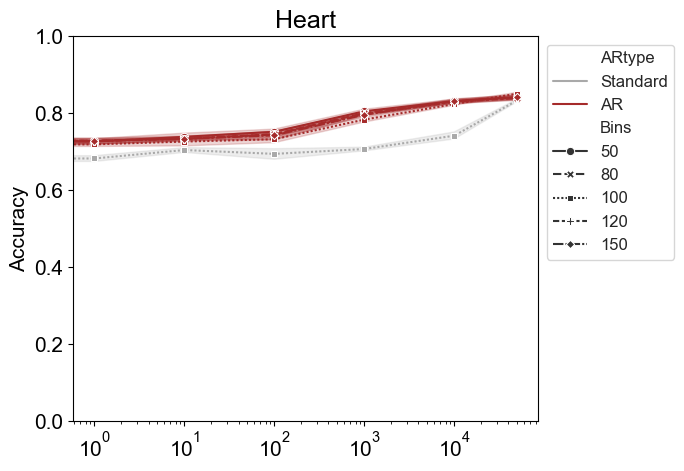

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Accuracy.png


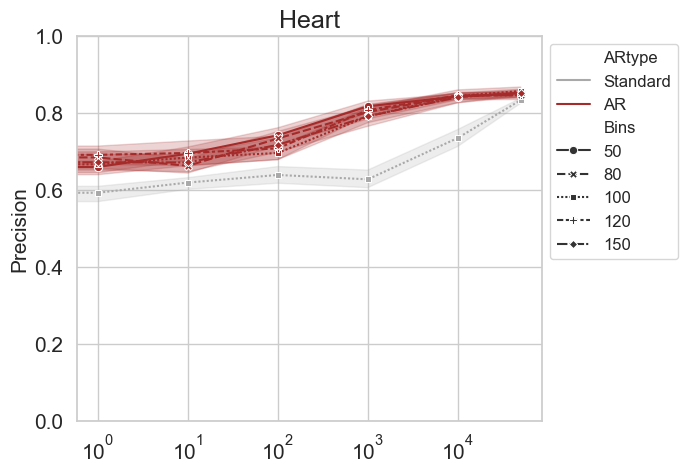

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Precision.png


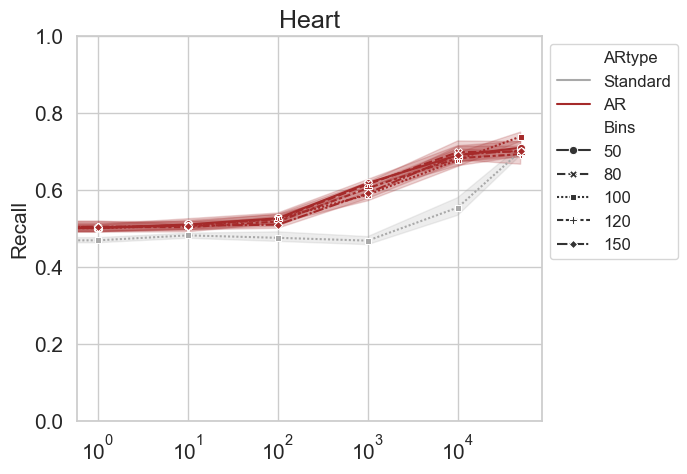

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Recall.png


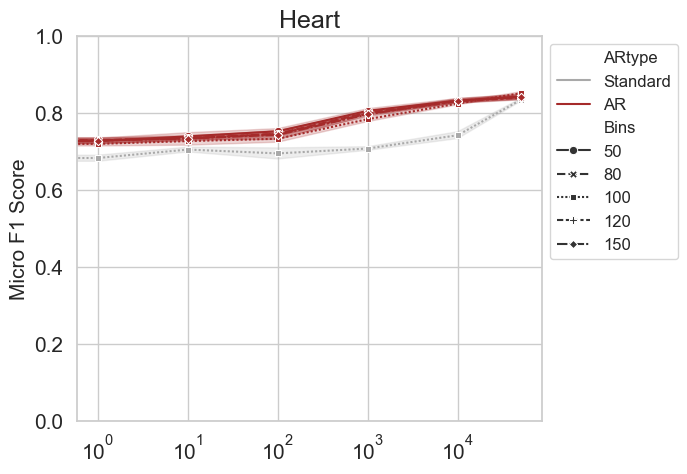

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Micro_F1_Score.png


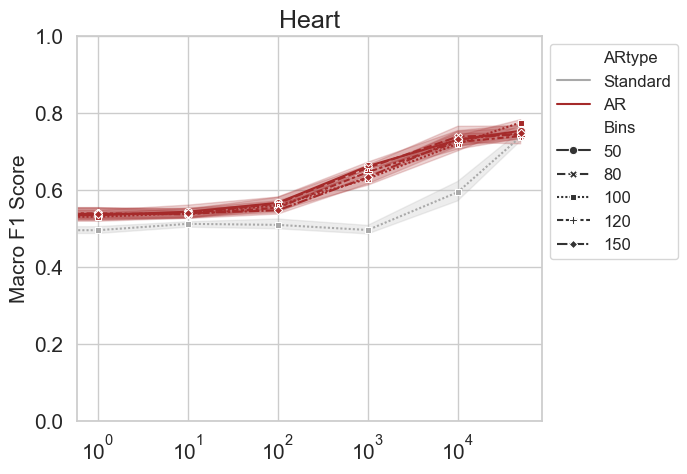

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Macro_F1_Score.png


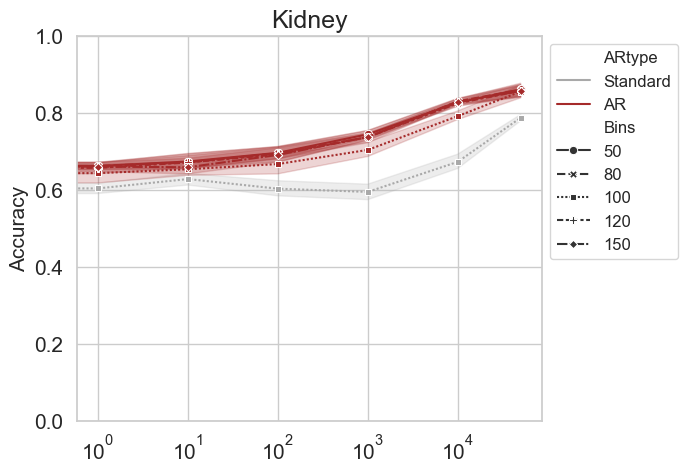

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Accuracy.png


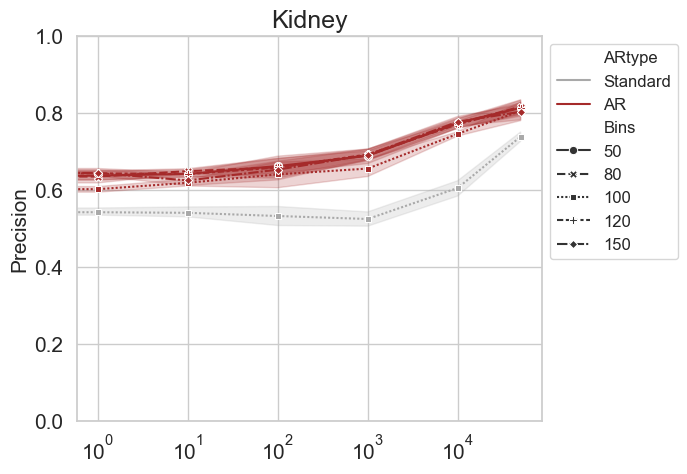

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Precision.png


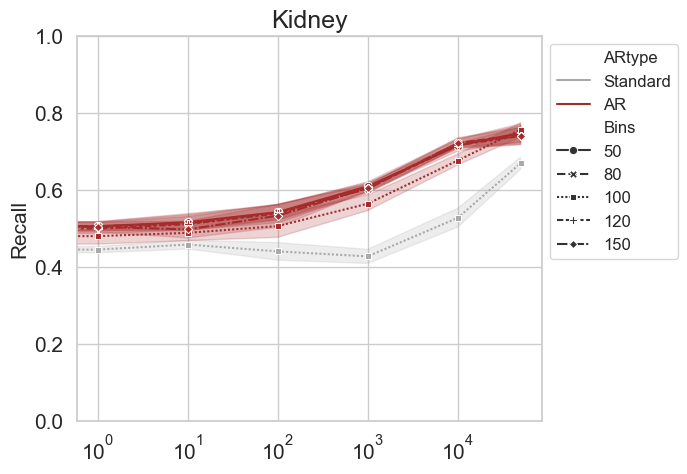

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Recall.png


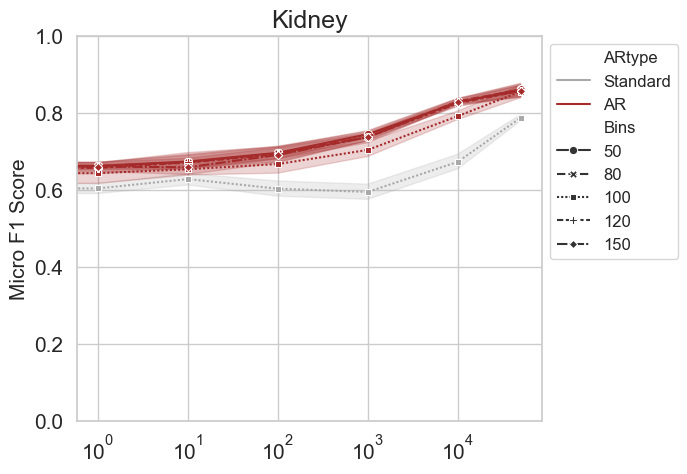

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Micro_F1_Score.png


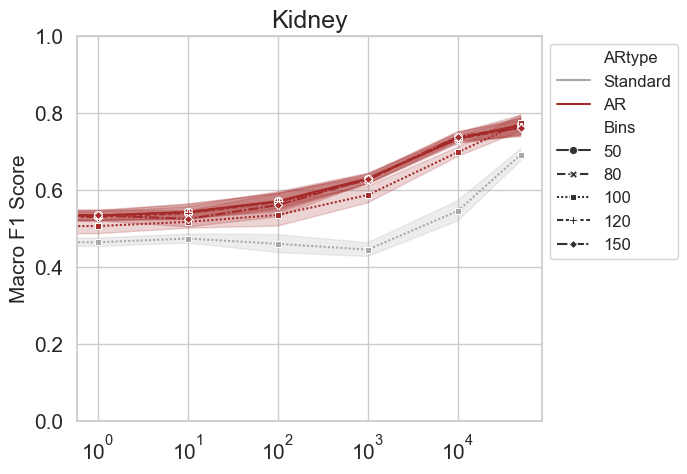

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Macro_F1_Score.png


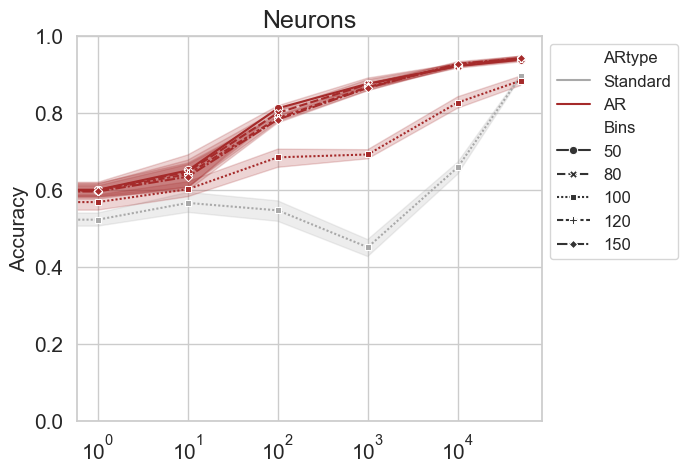

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Accuracy.png


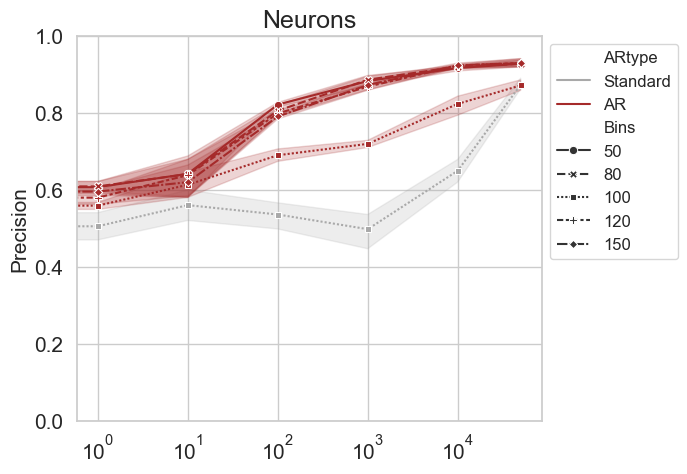

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Precision.png


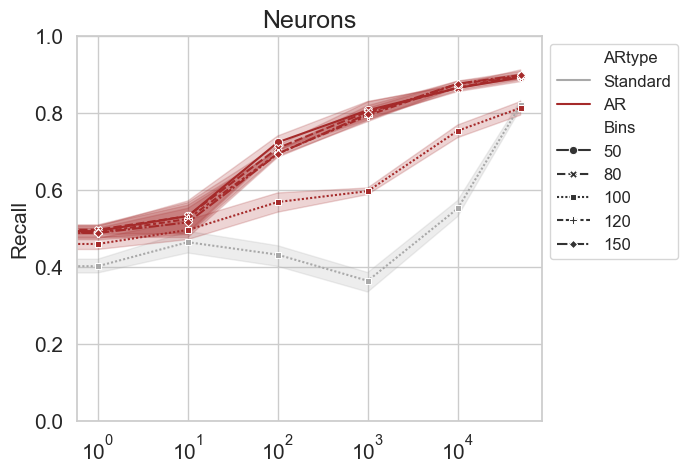

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Recall.png


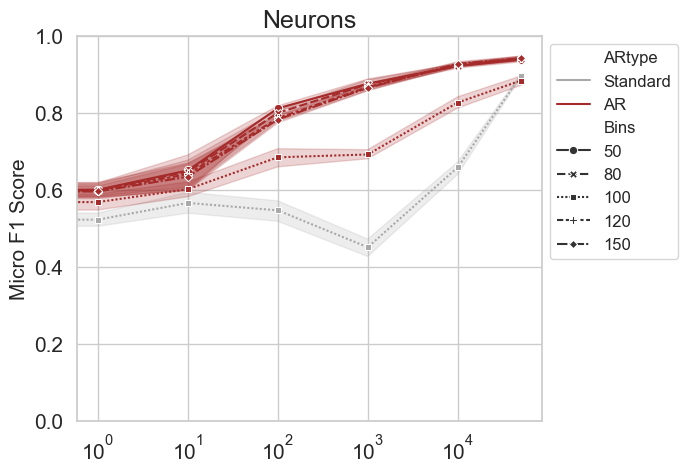

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Micro_F1_Score.png


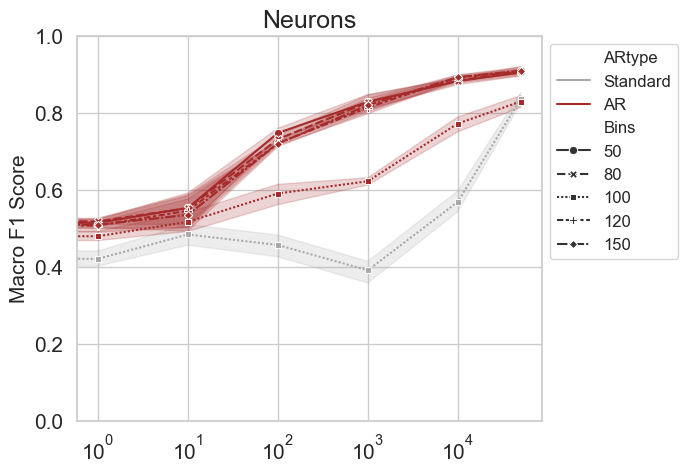

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Macro_F1_Score.png


In [4]:
for dataset in sorted(plot_df["dataset"].unique()):
    for metric in metrics:
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        g = sns.lineplot(
            data=plot_df[(plot_df["dataset"] == dataset) & (plot_df["metric"] == metric)],
            x="Atlas_cell_count",
            y="value",
            hue="ARtype",
            style="Bins",
            palette=PALETTE,
            hue_order=["Standard", "AR"],
            markers=True,
            dashes=True,
            ax=ax,
        )
        g.set_xlabel("")
        g.set_ylabel(metric, fontsize=15)
        g.set_title(dataset.capitalize(), fontsize=18)
        g.tick_params(axis="both", which="major", labelsize=15)
        g.legend(loc="upper left", fontsize=12, bbox_to_anchor=(1, 1))
        g.set(ylim=(0, 1))
        g.set_xscale("log", base=10)
        out = FIG_DIR / f"classification_{dataset}_{metric.replace(' ', '_')}.png"
        plt.savefig(out, dpi=600, bbox_inches="tight")
        plt.show()
        print("saved", out)

## Reconstruction metrics

In [5]:
RECON_NAME_RE = re.compile(
    r"Reconstruction_seed_(?P<seed>\d+)_ARtype_(?P<ARtype>[TF])_"
    r".*_Atlas_cell_count_(?P<atlas>\d+)_"
    r"(?:alpha_(?P<alpha>[0-9.eE+-]+)_)?"
    r"(?:bins_(?P<bins>\d+)_)?"
)


def normalize_recon_dataset(name: str) -> str:
    lower = name.lower()
    if "heart" in lower:
        return "Heart"
    if "kidney" in lower:
        return "Kidney"
    if "neuron" in lower:
        return "Neurons"
    return name


def load_reconstruction_pickles(pkl_dir: Path, default_bins=None, default_alpha=DEFAULT_ALPHA) -> pd.DataFrame:
    records = []
    for file in sorted(pkl_dir.glob("*.pkl")):
        if "Reconstruction_seed_" not in file.name:
            continue
        m = RECON_NAME_RE.search(file.name)
        if m is None:
            print("skip (unparsed):", file.name)
            continue
        seed = int(m.group("seed"))
        artype = m.group("ARtype")
        atlas = int(m.group("atlas"))
        alpha = float(m.group("alpha")) if m.group("alpha") else default_alpha
        bins = int(m.group("bins")) if m.group("bins") else default_bins
        if bins is None:
            raise ValueError(f"Could not determine bins for {file.name}")

        with open(file, "rb") as f:
            data = pickle.load(f)
        for key, test_df in data.items():
            records.append({
                "dataset": normalize_recon_dataset(key),
                "metric": "correlation",
                "value": float(test_df["correlation"].mean()),
                "ARtype": artype,
                "Atlas_cell_count": atlas,
                "seed": seed,
                "Bins": bins,
                "alpha": alpha,
            })
            records.append({
                "dataset": normalize_recon_dataset(key),
                "metric": "r2",
                "value": float(test_df["r2"].mean()),
                "ARtype": artype,
                "Atlas_cell_count": atlas,
                "seed": seed,
                "Bins": bins,
                "alpha": alpha,
            })
    return pd.DataFrame.from_records(records)


df_recon_bins = load_reconstruction_pickles(RECON_BIN_DIR)
df_recon_base = load_reconstruction_pickles(RECON_BASELINE_DIR, default_bins=DEFAULT_BINS)
df_recon = pd.concat([df_recon_bins, df_recon_base], ignore_index=True).drop_duplicates()

df_recon = df_recon[df_recon["seed"].isin(SEEDS)].copy()
df_recon = df_recon[df_recon["alpha"] == DEFAULT_ALPHA].copy()
df_recon["ARtype"] = df_recon["ARtype"].replace({"T": "AR", "F": "Standard"})
df_recon["Atlas_cell_count"] = df_recon["Atlas_cell_count"].astype(int)
df_recon["Bins"] = df_recon["Bins"].astype(int)
df_recon = df_recon.sort_values(by=["Bins", "Atlas_cell_count", "dataset", "metric"])

print("rows:", len(df_recon))
print("bins:", sorted(df_recon["Bins"].unique()))
print("ARtype:", df_recon["ARtype"].value_counts().to_dict())
print("coverage (dataset, Bins, ARtype) for correlation:")
print(
    df_recon[df_recon["metric"] == "correlation"]
    .groupby(["dataset", "Bins", "ARtype"])
    .size()
)
df_recon.head()

rows: 1260
bins: [50, 80, 100, 120, 150]
ARtype: {'AR': 1050, 'Standard': 210}
coverage (dataset, Bins, ARtype) for correlation:
dataset  Bins  ARtype  
Heart    50    AR          35
         80    AR          35
         100   AR          35
               Standard    35
         120   AR          35
         150   AR          35
Kidney   50    AR          35
         80    AR          35
         100   AR          35
               Standard    35
         120   AR          35
         150   AR          35
Neurons  50    AR          35
         80    AR          35
         100   AR          35
               Standard    35
         120   AR          35
         150   AR          35
dtype: int64


,dataset,metric,value,ARtype,Atlas_cell_count,seed,Bins,alpha
12,Heart,correlation,0.218587,AR,0,42,50,0.0001
180,Heart,correlation,0.225198,AR,0,43,50,0.0001
348,Heart,correlation,0.224340,AR,0,44,50,0.0001
516,Heart,correlation,0.212142,AR,0,45,50,0.0001
684,Heart,correlation,0.226576,AR,0,46,50,0.0001


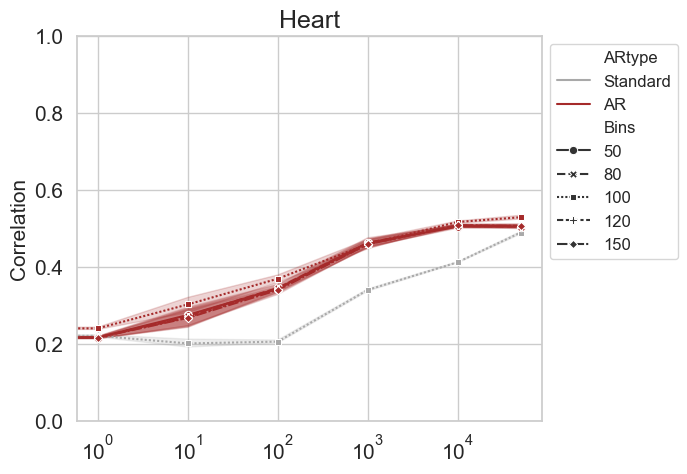

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/reconstruction_Heart_correlation.png


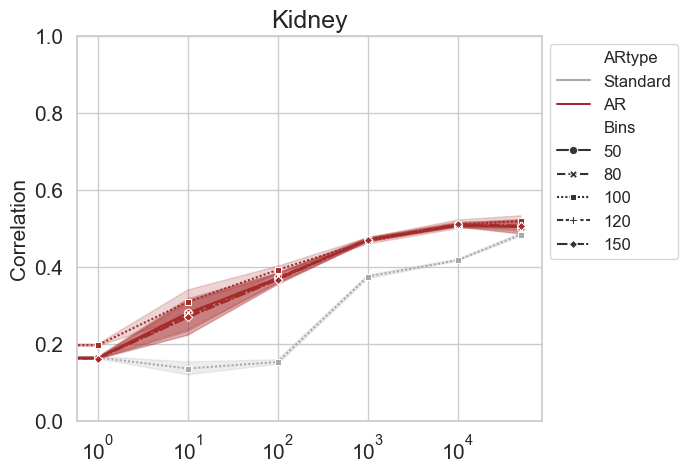

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/reconstruction_Kidney_correlation.png


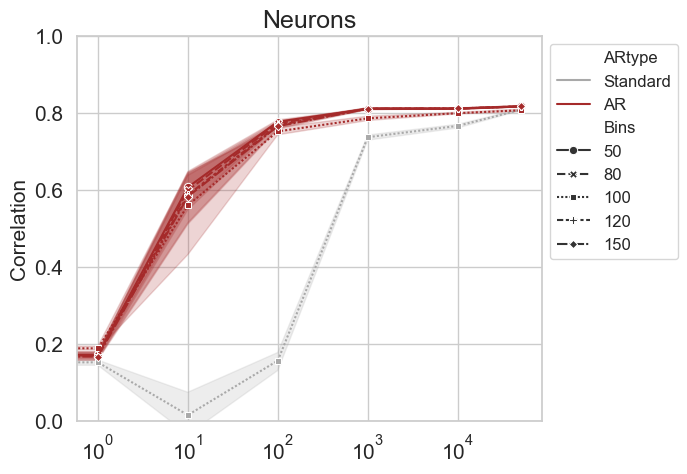

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/reconstruction_Neurons_correlation.png


In [6]:
for dataset in sorted(df_recon["dataset"].unique()):
    for metric in ["correlation"]:
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        g = sns.lineplot(
            data=df_recon[(df_recon["dataset"] == dataset) & (df_recon["metric"] == metric)],
            x="Atlas_cell_count",
            y="value",
            hue="ARtype",
            style="Bins",
            palette=PALETTE,
            hue_order=["Standard", "AR"],
            markers=True,
            dashes=True,
            ax=ax,
        )
        g.set_xlabel("")
        g.set_ylabel(metric.capitalize(), fontsize=15)
        g.set_title(dataset.capitalize(), fontsize=18)
        g.tick_params(axis="both", which="major", labelsize=15)
        g.set_xscale("log", base=10)
        g.legend(loc="upper left", fontsize=12, bbox_to_anchor=(1, 1))
        g.set(ylim=(0, 1))
        out = FIG_DIR / f"reconstruction_{dataset}_{metric}.png"
        plt.savefig(out, dpi=600, bbox_inches="tight")
        plt.show()
        print("saved", out)

## Notes

- New bin-count runs are **AR-only** (`ARtype=T`) for bins `{50, 80, 120, 150}`.
- Manuscript baseline supplies **Standard** and **AR** at `bins=100`.
- Some classification files are missing for `Atlas_cell_count=0` at a few seeds; seaborn will average over available seeds.
- Reconstruction pickles already contain Heart/Kidney/Neurons in one file per (seed, AR, atlas, bins).